In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import sqlite3
import requests

In [135]:
data = requests.get("https://l2h237eh53.execute-api.us-east-1.amazonaws.com/dev/precios?start_date=2024-03-15&end_date=2024-04-14")
data = data.json()

df = pd.DataFrame(data['data'])
df = df.reset_index()



In [136]:
df = df.rename(columns={'index' : 'hora'})
df = pd.melt(df, id_vars=['hora'], var_name='fecha', value_name='precio')


In [137]:
df['fecha'] = pd.to_datetime(df['fecha'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   hora    720 non-null    object        
 1   fecha   720 non-null    datetime64[ns]
 2   precio  716 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 17.0+ KB


In [138]:
dates = pd.date_range(start='2024-03-15', end='2024-04-14', freq='D')
len(dates)

31

In [139]:
df = df.replace({'24:00' : '00:00'})

In [38]:
df.isna().sum()

hora          0
2024-03-15    0
2024-03-16    0
2024-03-17    0
2024-03-19    0
2024-03-20    0
2024-03-21    0
2024-03-22    0
2024-03-23    0
2024-03-24    0
2024-03-25    0
2024-03-26    0
2024-03-27    0
2024-03-28    0
2024-03-29    0
2024-03-30    0
2024-03-31    0
2024-04-01    0
2024-04-02    0
2024-04-03    0
2024-04-04    0
2024-04-05    0
2024-04-06    0
2024-04-07    0
2024-04-08    1
2024-04-09    3
2024-04-10    0
2024-04-11    0
2024-04-12    0
2024-04-13    0
2024-04-14    0
dtype: int64

In [39]:
df['2024-04-08']

0      830.40
1      750.51
2      750.51
3      750.51
4      750.51
5      800.40
6      830.40
7      830.40
8      830.40
9      830.40
10     890.40
11    1025.40
12     965.40
13    1025.40
14        NaN
15    1025.40
16    1025.40
17    1025.40
18    1025.40
19    1030.40
20    1025.40
21    1025.40
22    1025.40
23     890.40
Name: 2024-04-08, dtype: float64

In [140]:
df['precio'] = df['precio'].ffill()
df

,hora,fecha,precio
0,01:00,2024-03-15,551.70
1,02:00,2024-03-15,551.70
2,03:00,2024-03-15,551.70
3,04:00,2024-03-15,497.36
4,05:00,2024-03-15,551.70
...,...,...,...
715,20:00,2024-04-14,1056.17
716,21:00,2024-04-14,1056.17
717,22:00,2024-04-14,1056.17
718,23:00,2024-04-14,1056.17


In [124]:
df[df['fecha'] == '2024-04-08']

,hora,fecha,precio
552,01:00,2024-04-08,830.40
553,02:00,2024-04-08,750.51
554,03:00,2024-04-08,750.51
555,04:00,2024-04-08,750.51
556,05:00,2024-04-08,750.51
557,06:00,2024-04-08,800.40
558,07:00,2024-04-08,830.40
559,08:00,2024-04-08,830.40
560,09:00,2024-04-08,830.40
561,10:00,2024-04-08,830.40


In [14]:
df.isna().sum()

hora      0
fecha     0
precio    0
dtype: int64

In [141]:
new_df = df.groupby('fecha')['precio'].mean()
new_df = new_df.reset_index()

In [108]:
new_df

,fecha,precio
0,2024-03-15,557.669167
1,2024-03-16,574.449167
2,2024-03-17,581.365000
3,2024-03-19,617.401667
4,2024-03-20,625.661667
5,2024-03-21,654.168333
6,2024-03-22,707.120417
7,2024-03-23,715.151250
8,2024-03-24,651.767500
9,2024-03-25,735.623333


In [144]:
new_df[((new_df['fecha'].dt.day < 18) & (new_df['fecha'].dt.day > 14)) | ((new_df['fecha'].dt.day > 18) & (new_df['fecha'].dt.day < 22))]

,fecha,precio
0,2024-03-15,557.669167
1,2024-03-16,574.449167
2,2024-03-17,581.365000
3,2024-03-19,617.401667
4,2024-03-20,625.661667
5,2024-03-21,654.168333


In [145]:
new_df = pd.concat([new_df, pd.DataFrame({'fecha': ['2024-03-18'], 'precio': [new_df[((new_df['fecha'].dt.day < 18) & (new_df['fecha'].dt.day > 14)) | ((new_df['fecha'].dt.day > 18) & (new_df['fecha'].dt.day < 22))]['precio'].mean()]})])
new_df

,fecha,precio
0,2024-03-15 00:00:00,557.669167
1,2024-03-16 00:00:00,574.449167
2,2024-03-17 00:00:00,581.365000
3,2024-03-19 00:00:00,617.401667
4,2024-03-20 00:00:00,625.661667
5,2024-03-21 00:00:00,654.168333
6,2024-03-22 00:00:00,707.120417
7,2024-03-23 00:00:00,715.151250
8,2024-03-24 00:00:00,651.767500
9,2024-03-25 00:00:00,735.623333


In [146]:
new_df['fecha'] = pd.to_datetime(new_df['fecha'])
new_df = new_df.set_index('fecha')


In [147]:
new_df = new_df.reset_index()

In [152]:
precio_7d = new_df.groupby((pd.Grouper(key='fecha', freq='7D')))['precio'].mean()
precio_7d = precio_7d.reset_index()
precio_7d = precio_7d.rename(columns={'precio': 'precio_7d'})
precio_7d

,fecha,precio_7d
0,2024-03-15,601.785833
1,2024-03-22,775.011190
2,2024-03-29,924.218155
3,2024-04-05,878.135714
4,2024-04-12,1028.546111


In [153]:
new_df = new_df.rename(columns={'precio': 'precio_promedio'})
#merged = pd.merge(new_df, precio_7d, on='fecha', how='left')


In [154]:
precio_7d = precio_7d.set_index('fecha')
precio_7d = precio_7d.resample('D').ffill()


In [155]:
precio_7d = precio_7d.reset_index()
new_df = new_df.reset_index()

In [156]:
merged = pd.merge(new_df, precio_7d, on='fecha', how='outer')
merged

,index,fecha,precio_promedio,precio_7d
0,0,2024-03-15,557.669167,601.785833
1,1,2024-03-16,574.449167,601.785833
2,2,2024-03-17,581.365000,601.785833
3,30,2024-03-18,601.785833,601.785833
4,3,2024-03-19,617.401667,601.785833
5,4,2024-03-20,625.661667,601.785833
6,5,2024-03-21,654.168333,601.785833
7,6,2024-03-22,707.120417,775.011190
8,7,2024-03-23,715.151250,775.011190
9,8,2024-03-24,651.767500,775.011190


In [158]:
merged = merged.ffill()
merged

,index,fecha,precio_promedio,precio_7d
0,0,2024-03-15,557.669167,601.785833
1,1,2024-03-16,574.449167,601.785833
2,2,2024-03-17,581.365000,601.785833
3,30,2024-03-18,601.785833,601.785833
4,3,2024-03-19,617.401667,601.785833
5,4,2024-03-20,625.661667,601.785833
6,5,2024-03-21,654.168333,601.785833
7,6,2024-03-22,707.120417,775.011190
8,7,2024-03-23,715.151250,775.011190
9,8,2024-03-24,651.767500,775.011190


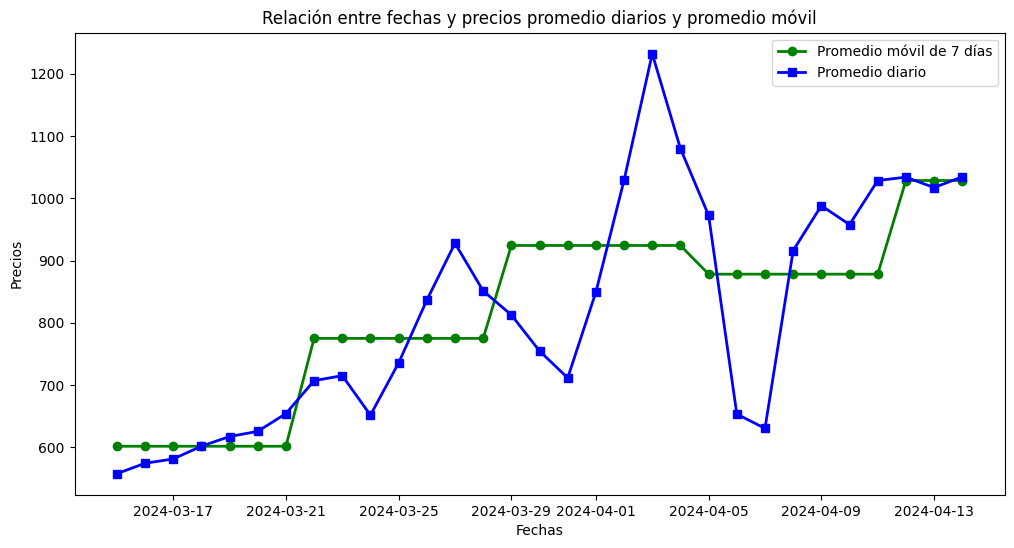

In [163]:
plt.figure(figsize=(12, 6))
plt.plot(merged['fecha'], merged['precio_7d'],  marker='o', color='green', linestyle='-', linewidth=2, label='Promedio móvil de 7 días')
plt.plot(merged['fecha'], merged['precio_promedio'],  marker='s', color='blue', linestyle='-', linewidth=2, label='Promedio diario')
plt.title("Relación entre fechas y precios promedio diarios y promedio móvil")
plt.xlabel('Fechas')
plt.ylabel('Precios')
plt.legend()
plt.savefig("image.png")
plt.show()


In [165]:
conn = sqlite3.connect("precios.db")

# Exportar el DataFrame a SQLite
merged.to_sql(name='precios', con=conn, if_exists='replace', index=False)

# Cerrar conexión
conn.close()

# Gracias por la oportunidad
**PD:** Estaba muy nervioso mientras estabamos en Teams, ya luego me relajé un poquito más y supe como seguir correctamente, logré completar toda la prueba y en breve iniciaré un curso de AWS ya que usted me indicó que era un conocimiento necesario, de modo que en caso de iniciar con ustedes ya tendré claro como usarlo o al menos una parte muy importante. Quedo pendiente a su revisión